Comparison between our conditional metrics bounds and Eq. (11) bounds from 

_An adaptive nearest neighbor rule for classification_. Akshay Balsubramani, Sanjoy Dasgupta, Yoav Freund and Shay Moran. Advances in Neural Information Processing Systems 32 (NeurIPS 2019).

In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
from python_scripts.sgp_utils import (
    emp_metric,
    our_bound,
)

In [3]:
datasets = [
    "../experiments/CIFAR/sgp_set_cnn",
    "../experiments/CIFAR/sgp_set_resnet",
    "../experiments/CIFAR/sgp_set_cnn_MCD",
    "../experiments/WSI/sgp_set_cnn",
    "../experiments/WSI/sgp_set_cnn_MCD",
]

In [4]:
num_points = 30

In [5]:
res_dicos = []
for dataset in datasets:

    print(dataset)

    data = "CIFAR" if ("CIFAR" in dataset) else "WSI"
    model = "cnn" if ("cnn" in dataset) else "resnet"
    kappa = "MCD" if ("MCD" in dataset) else "SR"

    dataset = pickle.load(open(dataset, "rb"))

    train_set = dataset.iloc[: int(3 * len(dataset) / 4)]
    train_set = (
        train_set.sort_values("kappa", ascending=True).reset_index(drop=True).copy()
    )
    test_set = dataset.iloc[int(3 * len(dataset) / 4) :]

    thetas = (
        np.linspace(0.5, 1, num_points)[:-1]
        if (kappa == "SR")
        else np.linspace(-0.05, 0, num_points)[:-1]
    )

    for metric in ["FPR", "FNR"]:

        print(metric)

        our_bounds = []
        eq11_bounds = []
        detailed_eq11_bounds = []
        test_metrics = []

        for theta in tqdm(thetas):
            selected_samples = train_set.loc[train_set.kappa >= theta].copy()
            our_bounds.append(our_bound(selected_samples, metric, n=train_set.shape[0]))

            # Bound from eq (11)
            eq11_bounds.append(eq11_bound(selected_samples, metric))
            detailed_eq11_bounds.append(
                eq11_bound(selected_samples, metric, detailed=True)
            )

            try:
                # test metric
                test_metrics.append(
                    emp_metric(
                        test_set.loc[test_set.kappa >= theta].copy(), metric=metric
                    )
                )
            except ValueError:
                test_metrics.append(np.nan)

        res_dicos.append(
            {
                "data": data,
                "model": model,
                "kappa": kappa,
                "metric": metric,
                "our_bounds": our_bounds,
                "eq11_bounds": eq11_bounds,
                "detailed_eq11_bounds": detailed_eq11_bounds,
                "test_metrics": test_metrics,
            }
        )

../experiments/CIFAR/sgp_set_cnn
FPR


100%|██████████| 29/29 [00:05<00:00,  4.89it/s]


FNR


100%|██████████| 29/29 [00:01<00:00, 27.40it/s]


../experiments/CIFAR/sgp_set_resnet
FPR


...

100%|██████████| 29/29 [00:00<00:00, 201.70it/s]


../experiments/WSI/sgp_set_cnn_MCD
FPR


100%|██████████| 29/29 [00:01<00:00, 24.05it/s]


FNR


100%|██████████| 29/29 [00:00<00:00, 139.44it/s]


In [6]:
df = pd.DataFrame(res_dicos)

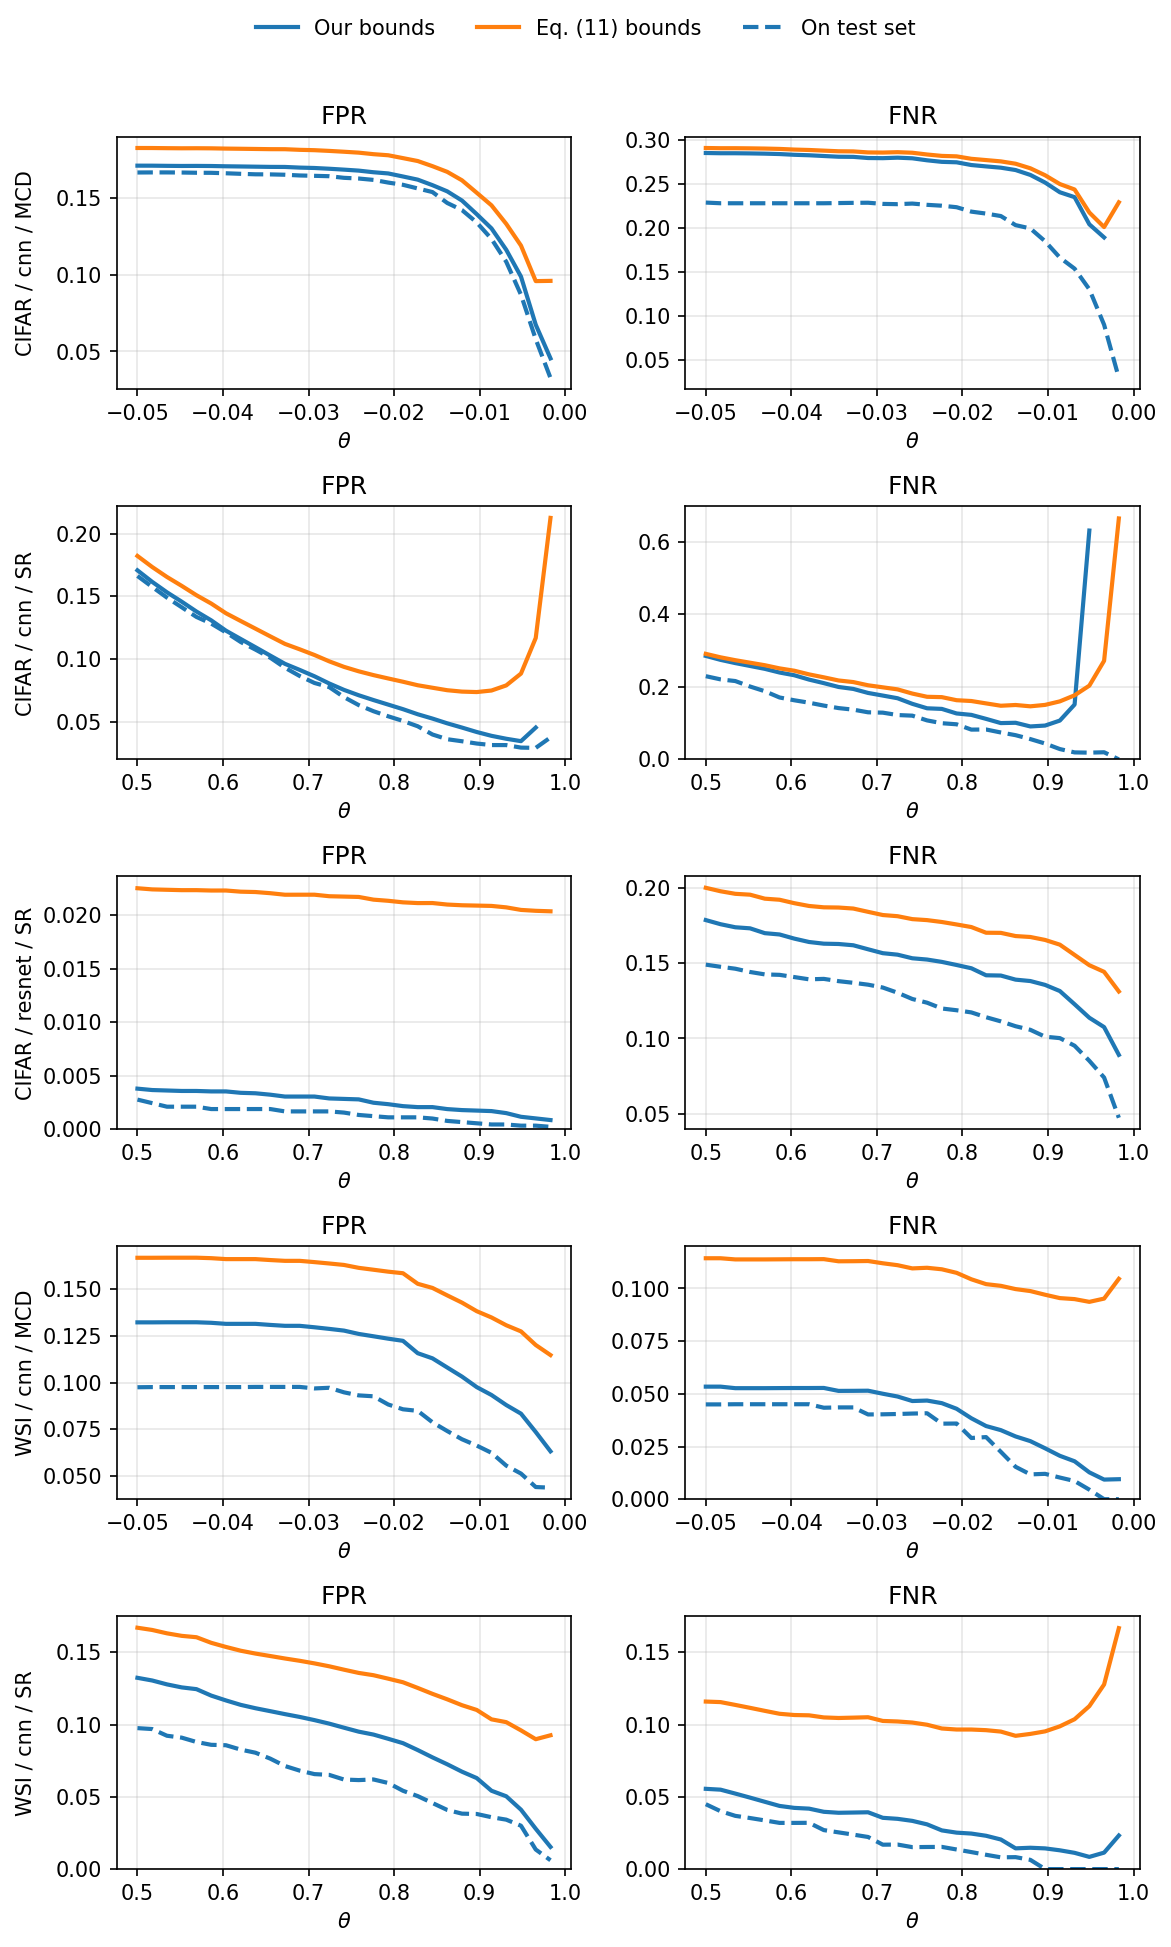

In [7]:
# --- layout: one row per (data, model, kappa)
metrics_order = ["FPR", "FNR"]
combos = (
    df[["data", "model", "kappa"]]
    .drop_duplicates()
    .sort_values(["data", "model", "kappa"])
    .itertuples(index=False, name=None)
)
combos = list(combos)
nrows = len(combos)
ncols = len(metrics_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.3 * ncols, 2.6 * nrows),
    squeeze=False,
)

series_cols = ["our_bounds", "eq11_bounds", "test_metrics"]
label_map = {
    "our_bounds": "Our bounds",
    "eq11_bounds": "Eq. (11) bounds",
    "test_metrics": "On test set",
}

# --- style settings
style_map = {
    "our_bounds": dict(color="C0", linestyle="-"),
    "test_metrics": dict(color="C0", linestyle="--"),
    "eq11_bounds": dict(color="C1", linestyle="-"),
}
LINEWIDTH = 2.0

for r, (data, model, kappa) in enumerate(combos):
    x = (
        np.linspace(0.5, 1, num_points)[:-1]
        if kappa == "SR"
        else np.linspace(-0.05, 0, num_points)[:-1]
    )

    sub = df[(df["data"] == data) & (df["model"] == model) & (df["kappa"] == kappa)]

    for c, metric in enumerate(metrics_order):
        ax = axes[r, c]
        row = sub[sub["metric"] == metric]
        if row.empty:
            ax.set_axis_off()
            continue

        row = row.iloc[0]

        for sc in series_cols:
            y = np.asarray(row[sc], dtype=float)
            ax.plot(
                x,
                y,
                label=label_map[sc],
                linewidth=LINEWIDTH,
                **style_map.get(sc, {}),
            )

        ax.set_title(metric)
        ax.set_xlabel(r"$\theta$")
        ax.grid(True, alpha=0.3)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(max(0, ymin), min(1, ymax))

        if c == 0:
            ax.text(
                -0.18,
                0.5,
                f"{data} / {model} / {kappa}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
            )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=[0.08, 0, 1, 0.96])
plt.show()

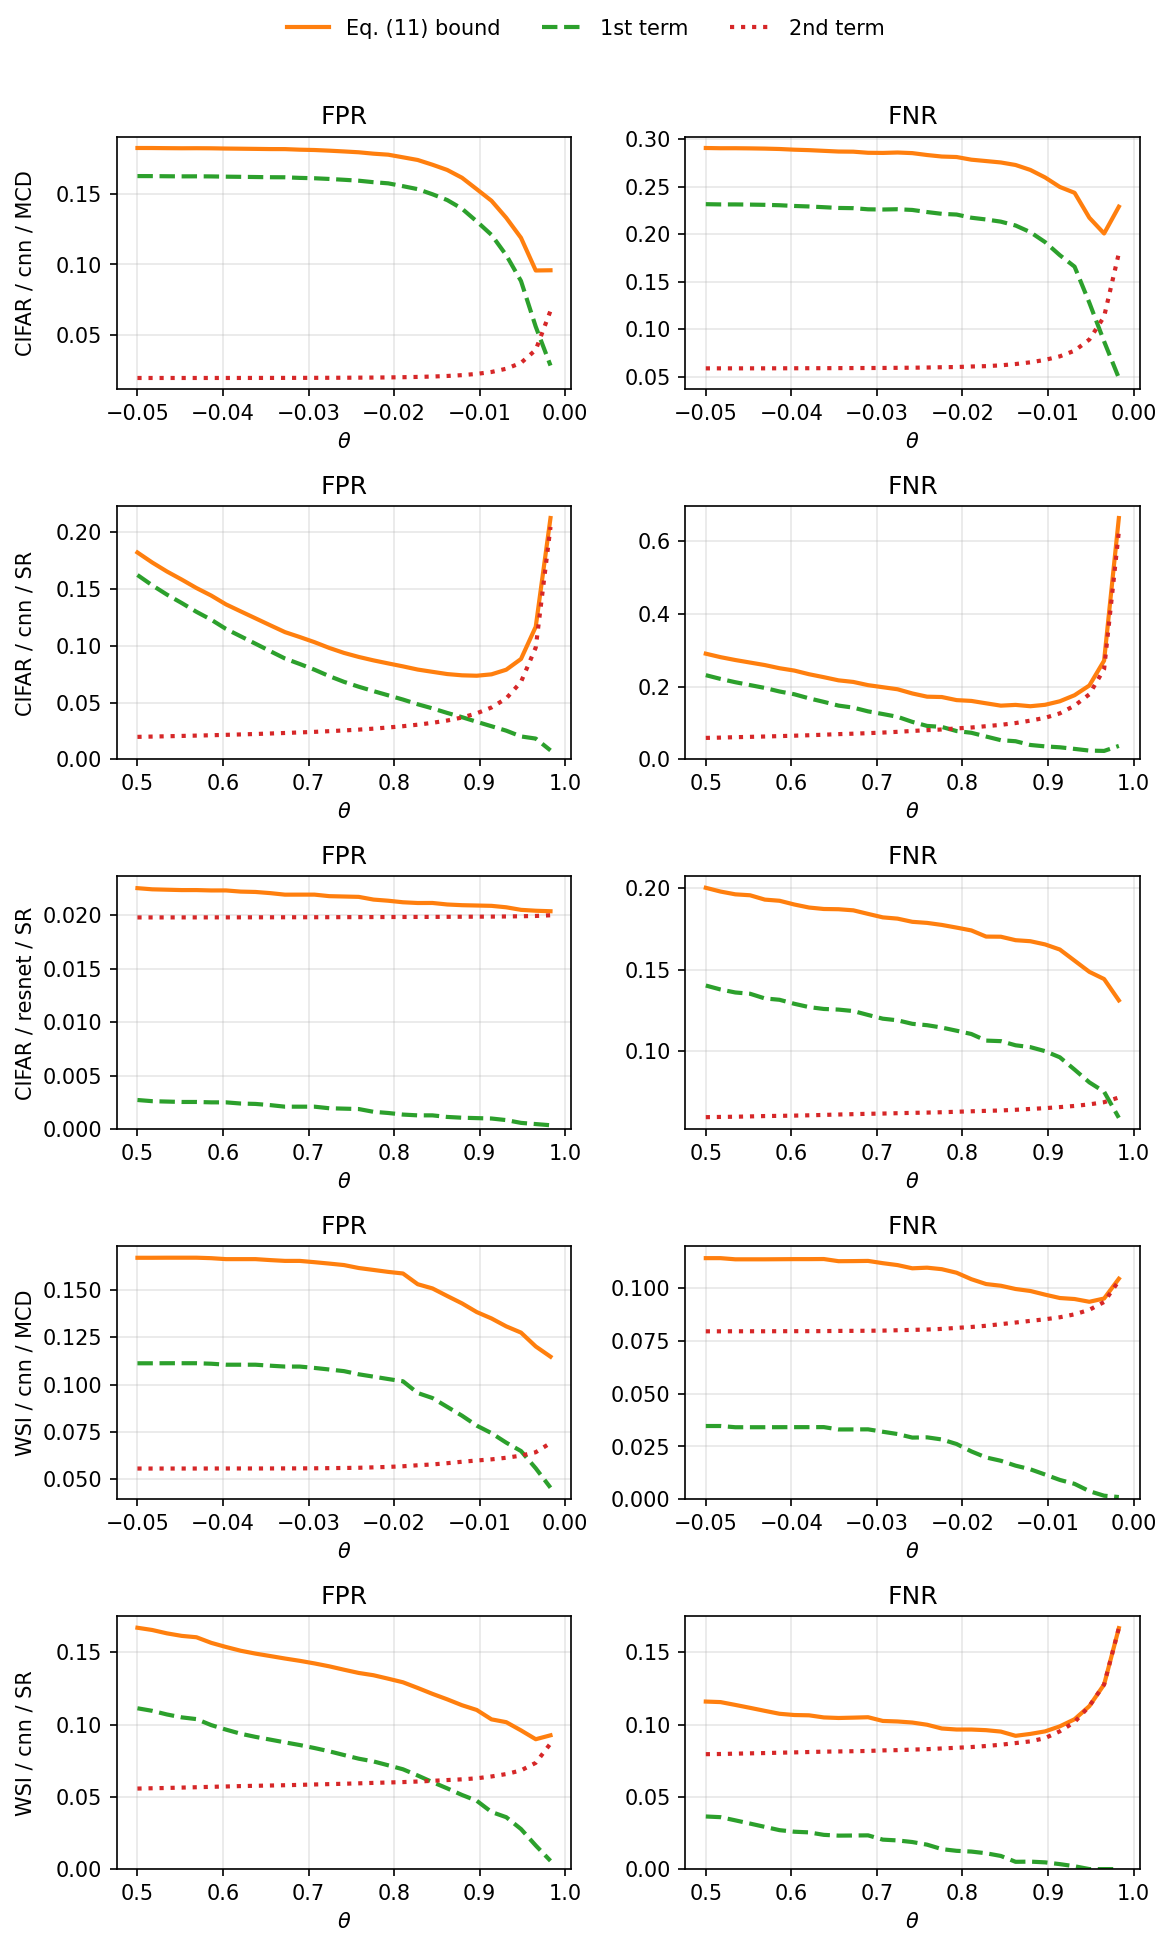

In [9]:
def extract_ab(v):
    """
    Turns detailed_eq11_bounds into two 1D arrays a, b.
    Accepts:
      - list of tuples/lists: [(a1, b1), (a2, b2), ...]
      - string representation of the above
      - array shaped (n, 2) or (2, n)
    """
    if isinstance(v, str):
        v = ast.literal_eval(v)

    arr = np.asarray(v, dtype=float)

    if arr.ndim != 2:
        raise ValueError(f"detailed_eq11_bounds should be 2D, got shape {arr.shape}")

    if arr.shape[1] == 2:  # shape (n, 2)
        a = arr[:, 0]
        b = arr[:, 1]
    elif arr.shape[0] == 2:  # shape (2, n)
        a = arr[0]
        b = arr[1]
    else:
        raise ValueError(
            f"Could not interpret detailed_eq11_bounds with shape {arr.shape}"
        )

    return a, b


# ---------- layout: one row per (data, model, kappa) ----------
metrics_order = ["FPR", "FNR"]
combos = (
    df[["data", "model", "kappa"]]
    .drop_duplicates()
    .sort_values(["data", "model", "kappa"])
    .itertuples(index=False, name=None)
)
combos = list(combos)
nrows = len(combos)
ncols = len(metrics_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.3 * ncols, 2.6 * nrows),
    squeeze=False,
)

# ---------- style ----------
label_map = {
    "eq11": "Eq. (11) bound",
    "a": "1st term",
    "b": "2nd term",
}

style_map = {
    "eq11": dict(color="C1", linestyle="-"),
    "a": dict(color="C2", linestyle="--"),
    "b": dict(color="C3", linestyle=":"),
}

LINEWIDTH = 2.0

for r, (data, model, kappa) in enumerate(combos):
    sub = df[(df["data"] == data) & (df["model"] == model) & (df["kappa"] == kappa)]

    for c, metric in enumerate(metrics_order):
        ax = axes[r, c]
        row = sub[sub["metric"] == metric]

        if row.empty:
            ax.set_axis_off()
            continue

        row = row.iloc[0]

        y_eq11 = np.asarray(row["eq11_bounds"], dtype=float)
        a, b = extract_ab(row["detailed_eq11_bounds"])

        # x-axis inferred from the length of the series
        n = len(y_eq11) + 1
        x = (
            np.linspace(0.5, 1, n)[:-1]
            if kappa == "SR"
            else np.linspace(-0.05, 0, n)[:-1]
        )

        # optional sanity check
        recon = a + b
        max_err = np.max(np.abs(y_eq11 - recon))
        if max_err > 1e-8:
            print(
                f"[warn] {data}/{model}/{kappa}/{metric}: "
                f"max |eq11 - (a+b)| = {max_err:.3e}"
            )

        ax.plot(
            x,
            y_eq11,
            label=label_map["eq11"],
            linewidth=LINEWIDTH,
            **style_map["eq11"],
        )
        ax.plot(
            x,
            a,
            label=label_map["a"],
            linewidth=LINEWIDTH,
            **style_map["a"],
        )
        ax.plot(
            x,
            b,
            label=label_map["b"],
            linewidth=LINEWIDTH,
            **style_map["b"],
        )

        ax.set_title(metric)
        ax.set_xlabel(r"$\theta$")
        ax.grid(True, alpha=0.3)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(max(0, ymin), min(1, ymax))

        if c == 0:
            ax.text(
                -0.18,
                0.5,
                f"{data} / {model} / {kappa}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
            )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=[0.08, 0, 1, 0.96])
plt.show()